In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Example images (public domain / common NST examples)
content_url = "https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"
style_url = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"

def load_image(url, max_size=400):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    size = max(image.size)
    if size > max_size:
        scale = max_size / size
        image = image.resize((int(image.size[0]*scale), int(image.size[1]*scale)))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ])
    return transform(image).unsqueeze(0).to(device)

content_img = load_image(content_url)
style_img = load_image(style_url)


In [3]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad_(False)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 125MB/s]


In [4]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    features = tensor.view(c, h*w)
    gram = torch.mm(features, features.t())
    return gram

class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()
    def forward(self, x):
        self.loss = nn.functional.mse_loss(x, self.target)
        return x

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()
    def forward(self, x):
        G = gram_matrix(x)
        self.loss = nn.functional.mse_loss(G, self.target)
        return x


In [5]:
content_layers = ['conv_4']
style_layers = ['conv_1','conv_2','conv_3','conv_4','conv_5']

cnn = vgg
model = nn.Sequential().to(device)

content_losses = []
style_losses = []

i = 0
for layer in cnn.children():
    if isinstance(layer, nn.Conv2d):
        i += 1
        name = f"conv_{i}"
    elif isinstance(layer, nn.ReLU):
        name = f"relu_{i}"
        layer = nn.ReLU(inplace=False)
    elif isinstance(layer, nn.MaxPool2d):
        name = f"pool_{i}"
    else:
        name = f"layer_{i}"

    model.add_module(name, layer)

    if name in content_layers:
        target = model(content_img).detach()
        content_loss = ContentLoss(target)
        model.add_module(f"content_loss_{i}", content_loss)
        content_losses.append(content_loss)

    if name in style_layers:
        target_feature = model(style_img).detach()
        style_loss = StyleLoss(target_feature)
        model.add_module(f"style_loss_{i}", style_loss)
        style_losses.append(style_loss)


In [7]:
input_img = content_img.clone()

optimizer = optim.LBFGS([input_img.requires_grad_()])

style_weight = 2e6   # Increased slightly to strengthen style effect
content_weight = 1

run = [0]
while run[0] <= 60:
    def closure():
        optimizer.zero_grad()
        model(input_img)

        style_score = sum(sl.loss for sl in style_losses)
        content_score = sum(cl.loss for cl in content_losses)

        loss = style_weight * style_score + content_weight * content_score
        loss.backward()

        run[0] += 1
        return loss

    optimizer.step(closure)


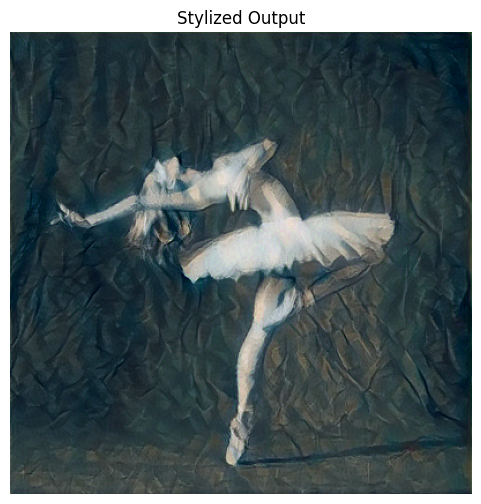

In [9]:
def show(tensor, title=None):
    image = tensor.detach().cpu().clone()
    image = image.squeeze(0)
    image = image * torch.tensor((0.229,0.224,0.225)).view(3,1,1)
    image = image + torch.tensor((0.485,0.456,0.406)).view(3,1,1)
    image = image.clamp(0,1)
    plt.imshow(image.permute(1,2,0))
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(6,6))
show(input_img, "Stylized Output")